<a href="https://colab.research.google.com/github/Mahfila/-Wellness-Companion-RAG/blob/main/New_L_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import random
from collections import deque
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA

class LSystem3D:
    """Full 3D L-system implementation with turtle graphics in 3D"""

    def __init__(self, axiom, rules, angle, distance=1.0, thickness=1.0):
        self.axiom = axiom
        self.rules = rules
        self.angle = np.radians(angle)  # Convert to radians
        self.distance = distance
        self.thickness = thickness
        self.state = axiom
        self.segments = []  # Store line segments for 3D plotting
        self.current_pos = np.array([0.0, 0.0, 0.0])
        self.current_dir = np.array([0.0, 0.0, 1.0])  # Start pointing up
        self.current_up = np.array([0.0, 1.0, 0.0])   # Initial up vector
        self.stack = []

    def rotate_vector(self, vector, axis, angle):
        """Rotate vector around axis by angle using Rodrigues' formula"""
        axis = axis / np.linalg.norm(axis)
        cos_a = np.cos(angle)
        sin_a = np.sin(angle)
        return (vector * cos_a +
                np.cross(axis, vector) * sin_a +
                axis * np.dot(axis, vector) * (1 - cos_a))

    def generate(self, iterations):
        """Generate the L-system string"""
        self.state = self.axiom
        for _ in range(iterations):
            new_state = ""
            for char in self.state:
                new_state += self.rules.get(char, char)
            self.state = new_state
        return self.state

    def interpret(self, iterations=0, stochastic=False):
        """Interpret the L-system and generate 3D coordinates"""
        if iterations > 0:
            self.generate(iterations)

        self.segments = []
        self.current_pos = np.array([0.0, 0.0, 0.0])
        self.current_dir = np.array([0.0, 0.0, 1.0])
        self.current_up = np.array([0.0, 1.0, 0.0])
        self.stack = []

        for char in self.state:
            if char == 'F':  # Move forward and draw
                start_pos = self.current_pos.copy()
                self.current_pos += self.current_dir * self.distance
                end_pos = self.current_pos.copy()
                self.segments.append((start_pos, end_pos, self.thickness))

            elif char == 'f':  # Move forward without drawing
                self.current_pos += self.current_dir * self.distance

            elif char == '+':  # Yaw right (rotate around up vector)
                self.current_dir = self.rotate_vector(self.current_dir, self.current_up, self.angle)

            elif char == '-':  # Yaw left
                self.current_dir = self.rotate_vector(self.current_dir, self.current_up, -self.angle)

            elif char == '&':  # Pitch down (rotate around right vector)
                right = np.cross(self.current_dir, self.current_up)
                self.current_dir = self.rotate_vector(self.current_dir, right, self.angle)
                self.current_up = self.rotate_vector(self.current_up, right, self.angle)

            elif char == '^':  # Pitch up
                right = np.cross(self.current_dir, self.current_up)
                self.current_dir = self.rotate_vector(self.current_dir, right, -self.angle)
                self.current_up = self.rotate_vector(self.current_up, right, -self.angle)

            elif char == '\\':  # Roll left (rotate around forward vector)
                self.current_up = self.rotate_vector(self.current_up, self.current_dir, self.angle)

            elif char == '/':  # Roll right
                self.current_up = self.rotate_vector(self.current_up, self.current_dir, -self.angle)

            elif char == '|':  # Reverse direction (turn 180 degrees)
                self.current_dir = -self.current_dir

            elif char == '[':  # Save state
                self.stack.append({
                    'pos': self.current_pos.copy(),
                    'dir': self.current_dir.copy(),
                    'up': self.current_up.copy(),
                    'thickness': self.thickness
                })
                self.thickness *= 0.7  # Branches get thinner

            elif char == ']':  # Restore state
                if self.stack:
                    state = self.stack.pop()
                    self.current_pos = state['pos']
                    self.current_dir = state['dir']
                    self.current_up = state['up']
                    self.thickness = state['thickness']

            elif char == '!':  # Decrease thickness
                self.thickness *= 0.9

            elif char == '(':  # Decrease step length
                self.distance *= 0.9

            elif char == ')':  # Increase step length
                self.distance *= 1.1

    def plot_3d(self, iterations=0, ax=None):
        """Plot the 3D L-system"""
        self.interpret(iterations)

        if ax is None:
            fig = plt.figure(figsize=(10, 8))
            ax = fig.add_subplot(111, projection='3d')

        # Plot each segment
        for start, end, thickness in self.segments:
            # Create line with thickness (simulated by multiple lines)
            line = np.array([start, end])
            ax.plot(line[:, 0], line[:, 1], line[:, 2],
                   color='brown', linewidth=thickness*2)

        # Set plot limits
        all_points = np.array([p for seg in self.segments for p in seg[:2]])
        if len(all_points) > 0:
            max_range = np.array([all_points[:, i].max() - all_points[:, i].min()
                                 for i in range(3)]).max() / 2.0
            mid_x = (all_points[:, 0].max() + all_points[:, 0].min()) * 0.5
            mid_y = (all_points[:, 1].max() + all_points[:, 1].min()) * 0.5
            mid_z = (all_points[:, 2].max() + all_points[:, 2].min()) * 0.5

            ax.set_xlim(mid_x - max_range, mid_x + max_range)
            ax.set_ylim(mid_y - max_range, mid_y + max_range)
            ax.set_zlim(mid_z - max_range, mid_z + max_range)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title('3D L-System Tree')

        return ax

# Advanced Tree Examples
def create_realistic_tree():
    """Create a realistic tree using 3D L-system"""
    axiom = "FA"

    rules = {
        'A': "![&(60)FA]/(137.5)[&(60)FA]/(137.5)[&(60)FA]",
        'F': "S/////F",
        'S': "FF"
    }

    lsys = LSystem3D(axiom, rules, angle=22.5, distance=2.0, thickness=3.0)
    return lsys

def create_pine_tree():
    """Create a pine tree"""
    axiom = "SA"

    rules = {
        'A': "![&(30)FB]/(120)[&(30)FB]/(120)[&(30)FB]",
        'B': "[&(45)FC]",
        'C': "[&(45)FD]",
        'D': "[&(45)FE]",
        'E': "F",
        'F': "S/////F",
        'S': "FF"
    }

    lsys = LSystem3D(axiom, rules, angle=20, distance=1.5, thickness=2.5)
    return lsys

def create_bush():
    """Create a bush"""
    axiom = "F"

    rules = {
        'F': "F[+&F][-&F][\\F][/F]"
    }

    lsys = LSystem3D(axiom, rules, angle=30, distance=1.0, thickness=1.5)
    return lsys

# Stochastic 3D L-system
class StochasticLSystem3D(LSystem3D):
    """3D L-system with probabilistic rules"""

    def generate(self, iterations, temperature=1.0):
        """Generate with stochastic rules"""
        self.state = self.axiom
        for _ in range(iterations):
            new_state = ""
            for char in self.state:
                if char in self.rules:
                    rules_list = self.rules[char]
                    if isinstance(rules_list, list):
                        # Choose based on probability
                        total = sum(r[1] for r in rules_list)
                        r = random.random() * total
                        accum = 0
                        for rule, prob in rules_list:
                            accum += prob
                            if r <= accum:
                                new_state += rule
                                break
                    else:
                        new_state += rules_list
                else:
                    new_state += char
            self.state = new_state
        return self.state

def create_stochastic_tree():
    """Create a tree with stochastic variations"""
    axiom = "FA"

    rules = {
        'A': [
            ("![&(60)FA]/(137.5)[&(60)FA]", 0.4),
            ("![&(45)FA]/(120)[&(45)FA]/(120)[&(45)FA]", 0.4),
            ("![&(30)FA]/(90)[&(30)FA]", 0.2)
        ],
        'F': "S/////F",
        'S': [("FF", 0.7), ("F", 0.3)]
    }

    lsys = StochasticLSystem3D(axiom, rules, angle=22.5, distance=1.8, thickness=2.8)
    return lsys

# Visualization function
def visualize_multiple_trees():
    """Visualize different tree types"""
    trees = [
        ("Realistic Tree", create_realistic_tree()),
        ("Pine Tree", create_pine_tree()),
        ("Bush", create_bush()),
        ("Stochastic Tree", create_stochastic_tree())
    ]

    fig = plt.figure(figsize=(15, 12))

    for idx, (title, tree) in enumerate(trees, 1):
        ax = fig.add_subplot(2, 2, idx, projection='3d')
        tree.plot_3d(iterations=5, ax=ax)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

Part 2: L-System String Processing and Analysis

In [2]:
class LSystemAnalyzer:
    """Tools for analyzing and manipulating L-system strings"""

    @staticmethod
    def parse_l_string(l_string):
        """Parse L-string into structured format"""
        # This is a simplified parser - in practice you'd want a full grammar parser
        tokens = []
        i = 0
        while i < len(l_string):
            char = l_string[i]

            # Check for parameters
            if i + 1 < len(l_string) and l_string[i+1] == '(':
                j = i + 2
                while j < len(l_string) and l_string[j] != ')':
                    j += 1
                param = l_string[i+2:j] if j < len(l_string) else ""
                tokens.append((char, param))
                i = j + 1
            else:
                tokens.append((char, ""))
                i += 1

        return tokens

    @staticmethod
    def compute_statistics(l_string):
        """Compute various statistics about L-string"""
        stats = {
            'length': len(l_string),
            'branching_factor': l_string.count('[') / max(l_string.count('F'), 1),
            'symmetry_score': abs(l_string.count('+') - l_string.count('-')) /
                            max(l_string.count('+') + l_string.count('-'), 1),
            'depth': 0,
            'max_depth': 0,
            'segment_count': l_string.count('F'),
            'leaf_count': l_string.count('L') if 'L' in l_string else 0
        }

        # Calculate nesting depth
        current_depth = 0
        for char in l_string:
            if char == '[':
                current_depth += 1
                stats['max_depth'] = max(stats['max_depth'], current_depth)
            elif char == ']':
                current_depth -= 1
        stats['depth'] = stats['max_depth']

        return stats

    @staticmethod
    def generate_from_params(params):
        """Generate L-string from high-level parameters"""
        # params dict should contain: complexity, branching, symmetry, etc.
        complexity = params.get('complexity', 0.5)
        branching = params.get('branching', 0.5)
        symmetry = params.get('symmetry', 0.5)

        # Simplified generation - in practice this would be more sophisticated
        axiom = "F"
        rules = {}

        # Generate rules based on parameters
        if complexity > 0.7:
            rules['F'] = "F[+F]F[-F]F"
        elif complexity > 0.4:
            rules['F'] = "F[+F][-F]"
        else:
            rules['F'] = "F[+F]"

        # Adjust for symmetry
        if symmetry > 0.7:
            # More symmetric
            rules['F'] = rules['F'].replace(']', ']').replace('[', '[')

        return axiom, rules

    @staticmethod
    def compare_l_strings(l_string1, l_string2):
        """Compare two L-strings for similarity"""
        # Simple comparison - could use more sophisticated metrics
        tokens1 = LSystemAnalyzer.parse_l_string(l_string1)
        tokens2 = LSystemAnalyzer.parse_l_string(l_string2)

        # Convert to sets of n-grams for comparison
        def get_ngrams(tokens, n=3):
            return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

        ngrams1 = set(get_ngrams(tokens1, 2))
        ngrams2 = set(get_ngrams(tokens2, 2))

        if not ngrams1 or not ngrams2:
            return 0

        intersection = len(ngrams1.intersection(ngrams2))
        union = len(ngrams1.union(ngrams2))

        return intersection / union if union > 0 else 0

# Example usage of analyzer
def analyze_example():
    lsys = create_realistic_tree()
    lsys.generate(4)

    analyzer = LSystemAnalyzer()
    stats = analyzer.compute_statistics(lsys.state)

    print("L-System Statistics:")
    for key, value in stats.items():
        print(f"  {key}: {value:.3f}")

    # Generate from parameters
    params = {'complexity': 0.8, 'branching': 0.6, 'symmetry': 0.9}
    axiom, rules = analyzer.generate_from_params(params)
    print(f"\nGenerated from params:")
    print(f"  Axiom: {axiom}")
    print(f"  Rules: {rules}")

Part 3: Neural Network for Latent L-Systems

ADVANCED L-SYSTEMS WITH LATENT SPACE LEARNING

1. Visualizing 3D L-System Trees...


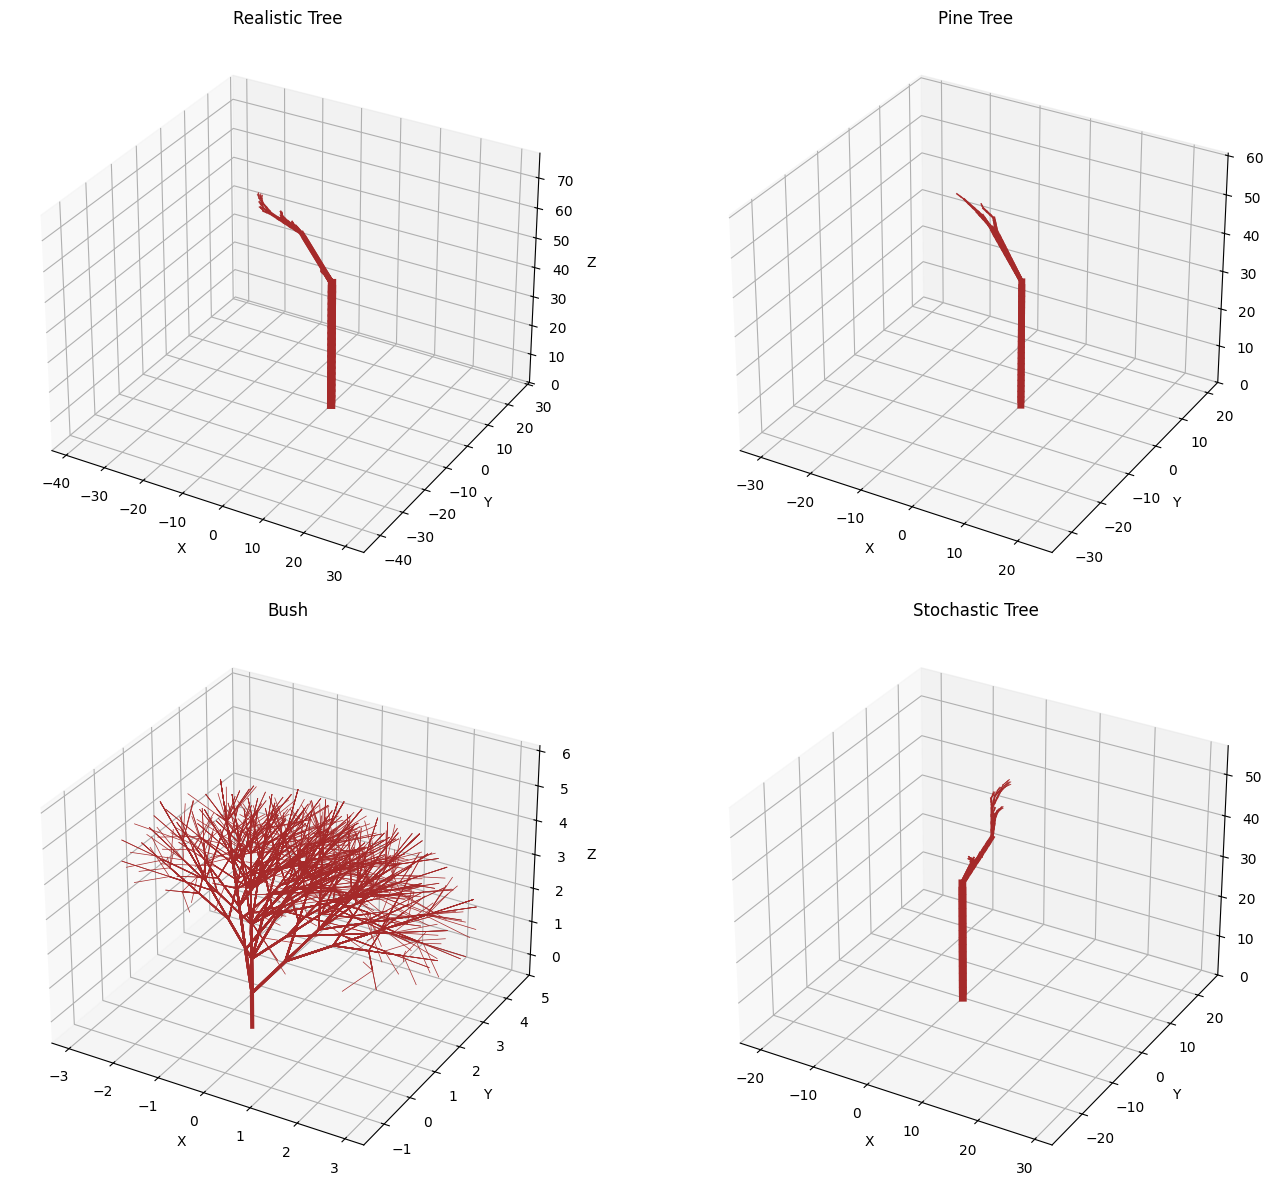


2. Analyzing L-System Statistics...
L-System Statistics:
  length: 2162.000
  branching_factor: 0.745
  symmetry_score: 0.000
  depth: 4.000
  max_depth: 4.000
  segment_count: 161.000
  leaf_count: 0.000

Generated from params:
  Axiom: F
  Rules: {'F': 'F[+F]F[-F]F'}

3. Training Latent L-System Model...
Generating training data...
Training VAE...
Note: Neural network training requires PyTorch. Error: input.size(-1) must be equal to input_size. Expected 128, got 32
Install with: pip install torch

Additional Resources:
1. L-system parameters can be controlled via the latent space
2. The VAE learns to generate valid L-strings
3. Interpolate in latent space to morph between tree structures


In [ ]:
class LSystemVAE(nn.Module):
    """Variational Autoencoder for learning latent representations of L-systems"""

    def __init__(self, vocab_size=50, embedding_dim=32, hidden_dim=128, latent_dim=16):
        super(LSystemVAE, self).__init__()

        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.encoder_gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Latent space
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder_gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.decoder_out = nn.Linear(hidden_dim, vocab_size)

        # Attention mechanism (optional)
        self.attention = nn.MultiheadAttention(embedding_dim, num_heads=4)

    def encode(self, x):
        """Encode input sequence to latent space"""
        embedded = self.encoder_embedding(x)

        # Apply attention
        embedded = embedded.permute(1, 0, 2)  # [seq_len, batch, features]
        attended, _ = self.attention(embedded, embedded, embedded)
        attended = attended.permute(1, 0, 2)  # [batch, seq_len, features]

        _, hidden = self.encoder_gru(attended)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # Concatenate bidirectional

        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Reparameterization trick"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, max_length=100, temperature=1.0):
        """Decode from latent space to sequence"""
        batch_size = z.size(0)

        # Initial hidden state
        hidden = self.decoder_fc(z).unsqueeze(0)

        # Start with <SOS> token (assuming 0 is SOS)
        input_token = torch.zeros(batch_size, 1, dtype=torch.long).to(z.device)

        outputs = []

        for _ in range(max_length):
            embedded = self.encoder_embedding(input_token)
            output, hidden = self.decoder_gru(embedded, hidden)
            logits = self.decoder_out(output) / temperature

            # Sample next token
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs.squeeze(1), 1)

            outputs.append(next_token)
            input_token = next_token

            # Stop if <EOS> token (assuming 1 is EOS)
            if (next_token == 1).all():
                break

        outputs = torch.cat(outputs, dim=1)
        return outputs

    def forward(self, x, max_length=100):
        """Full forward pass"""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z, max_length)

        return reconstructed, mu, logvar

    def loss_function(self, recon_x, x, mu, logvar):
        """VAE loss function"""
        # Reconstruction loss
        recon_loss = F.cross_entropy(
            recon_x.view(-1, self.vocab_size),
            x.view(-1),
            reduction='mean'
        )

        # KL divergence
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        kl_loss = kl_loss.mean()

        return recon_loss + 0.1 * kl_loss, recon_loss, kl_loss

class LSystemDataset:
    """Dataset for L-system strings"""

    def __init__(self, l_systems, vocab=None, max_length=200):
        self.l_systems = l_systems
        self.max_length = max_length

        if vocab is None:
            self.vocab = self.build_vocab()
        else:
            self.vocab = vocab

        self.vocab_size = len(self.vocab)

    def build_vocab(self):
        """Build vocabulary from all L-systems"""
        chars = set()
        for lsys in self.l_systems:
            chars.update(lsys)

        vocab = {char: idx + 2 for idx, char in enumerate(sorted(chars))}
        vocab['<SOS>'] = 0  # Start of sequence
        vocab['<EOS>'] = 1  # End of sequence
        vocab['<PAD>'] = len(vocab)  # Padding

        return vocab

    def encode(self, l_string):
        """Encode L-string to tensor"""
        tokens = [self.vocab[char] for char in l_string[:self.max_length]]
        tokens = [self.vocab['<SOS>']] + tokens + [self.vocab['<EOS>']]

        # Pad to max_length
        if len(tokens) < self.max_length + 2:
            tokens += [self.vocab['<PAD>']] * (self.max_length + 2 - len(tokens))

        return torch.tensor(tokens[:self.max_length + 2])

    def decode(self, tensor):
        """Decode tensor to L-string"""
        tokens = tensor.tolist()
        # Remove special tokens and padding
        tokens = [t for t in tokens if t not in [0, 1, self.vocab['<PAD>']]]

        # Reverse vocab lookup
        rev_vocab = {v: k for k, v in self.vocab.items()}
        chars = [rev_vocab.get(t, '?') for t in tokens]

        return ''.join(chars)

    def __len__(self):
        return len(self.l_systems)

    def __getitem__(self, idx):
        l_string = self.l_systems[idx]
        return self.encode(l_string)

def generate_training_data(n_samples=1000):
    """Generate training data by varying L-system parameters"""
    l_strings = []

    for _ in range(n_samples):
        # Random parameters
        complexity = random.uniform(0.3, 0.9)
        branching = random.uniform(0.3, 0.9)
        symmetry = random.uniform(0.3, 0.9)

        # Create L-system with these parameters
        axiom = "F"

        # Simple rule generation based on parameters
        if complexity > 0.7:
            if symmetry > 0.7:
                rule = "F[+F][-F]F[+F][-F]"
            else:
                rule = f"F[+{''.join(['F']*int(branching*3))}][-{''.join(['F']*int(branching*2))}]"
        elif complexity > 0.5:
            rule = "F[+F][-F]"
        else:
            rule = "F[+F]"

        rules = {'F': rule}

        # Generate L-string
        lsys = LSystem3D(axiom, rules, angle=random.uniform(20, 40),
                        distance=random.uniform(0.5, 2.0))
        lsys.generate(iterations=random.randint(3, 6))

        l_strings.append(lsys.state[:100])  # Limit length

    return l_strings

def train_latent_lsystem():
    """Train the VAE on L-system data"""
    # Generate training data
    print("Generating training data...")
    l_strings = generate_training_data(5000)

    # Create dataset
    dataset = LSystemDataset(l_strings, max_length=100)

    # Create model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSystemVAE(
        vocab_size=dataset.vocab_size,
        embedding_dim=32,
        hidden_dim=128,
        latent_dim=8
    ).to(device)

    # Training setup
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    # Training loop
    print("Training VAE...")
    model.train()
    for epoch in range(50):
        total_loss = 0
        total_recon = 0
        total_kl = 0

        for batch in dataloader:
            batch = batch.to(device)

            optimizer.zero_grad()

            recon_batch, mu, logvar = model(batch)
            loss, recon_loss, kl_loss = model.loss_function(recon_batch, batch, mu, logvar)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}: Loss={total_loss/len(dataloader):.4f}, '
                  f'Recon={total_recon/len(dataloader):.4f}, '
                  f'KL={total_kl/len(dataloader):.4f}')

    # Test generation from latent space
    print("\nTesting generation from latent space...")
    model.eval()

    with torch.no_grad():
        # Sample from latent space
        z = torch.randn(1, model.latent_dim).to(device)

        # Generate new L-string
        generated = model.decode(z, max_length=50, temperature=0.8)
        generated_string = dataset.decode(generated[0])

        print(f"Generated L-string: {generated_string[:100]}...")

        # Interpolate between two points in latent space
        z1 = torch.randn(1, model.latent_dim).to(device)
        z2 = torch.randn(1, model.latent_dim).to(device)

        print("\nLatent space interpolation:")
        for alpha in [0, 0.25, 0.5, 0.75, 1]:
            z_interp = (1 - alpha) * z1 + alpha * z2
            generated = model.decode(z_interp, max_length=50, temperature=0.8)
            interp_string = dataset.decode(generated[0])
            print(f"Alpha={alpha}: {interp_string[:50]}...")

    return model, dataset

class LatentSpaceExplorer:
    """Interactive exploration of latent space"""

    def __init__(self, model, dataset):
        self.model = model
        self.dataset = dataset
        self.device = next(model.parameters()).device

    def interpolate(self, z1, z2, steps=10):
        """Interpolate between two latent vectors"""
        interpolated = []

        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * z1 + alpha * z2
            with torch.no_grad():
                generated = self.model.decode(z.unsqueeze(0), max_length=100, temperature=0.7)
                l_string = self.dataset.decode(generated[0])
                interpolated.append(l_string)

        return interpolated

    def visualize_latent_space(self, l_strings, n_samples=100):
        """Visualize L-strings in 2D latent space using PCA"""
        # Encode samples
        encoded = []
        for l_string in random.sample(l_strings, min(n_samples, len(l_strings))):
            tensor = self.dataset.encode(l_string).unsqueeze(0).to(self.device)
            with torch.no_grad():
                mu, _ = self.model.encode(tensor)
                encoded.append(mu.cpu().numpy())

        encoded = np.vstack(encoded)

        # Apply PCA
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(encoded)

        # Plot
        plt.figure(figsize=(10, 8))
        plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.6)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('L-System Latent Space (PCA)')
        plt.grid(True, alpha=0.3)

        # Highlight some examples
        for i in range(min(5, len(reduced))):
            plt.annotate(f'Sample {i+1}',
                        (reduced[i, 0], reduced[i, 1]),
                        textcoords="offset points",
                        xytext=(0,10),
                        ha='center')

        return plt

# Main execution
if __name__ == "__main__":
    print("=" * 60)
    print("ADVANCED L-SYSTEMS WITH LATENT SPACE LEARNING")
    print("=" * 60)

    # Option 1: Visualize 3D trees
    print("\n1. Visualizing 3D L-System Trees...")
    visualize_multiple_trees()

    # Option 2: Analyze L-strings
    print("\n2. Analyzing L-System Statistics...")
    analyze_example()

    # Option 3: Train latent L-system model
    print("\n3. Training Latent L-System Model...")
    try:
        model, dataset = train_latent_lsystem()

        # Create latent space explorer
        explorer = LatentSpaceExplorer(model, dataset)

        # Generate some L-strings for visualization
        l_strings = generate_training_data(200)

        # Visualize latent space
        print("\n4. Visualizing Latent Space...")
        plt = explorer.visualize_latent_space(l_strings, n_samples=100)
        plt.show()

    except Exception as e:
        print(f"Note: Neural network training requires PyTorch. Error: {e}")
        print("Install with: pip install torch")

    print("\n" + "=" * 60)
    print("Additional Resources:")
    print("1. L-system parameters can be controlled via the latent space")
    print("2. The VAE learns to generate valid L-strings")
    print("3. Interpolate in latent space to morph between tree structures")
    print("=" * 60)

In [3]:
# First, install required packages
!pip install plotly kaleido -q
!apt-get install -y xvfb  # For headless display
!pip install pyvirtualdisplay -q

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, VBox, HBox, Layout
import random
from datetime import datetime

# Enable Plotly in Colab
pio.renderers.default = 'colab'

class ColabLSystem3D:
    """3D L-system optimized for Colab visualization"""

    def __init__(self, axiom, rules, angle, distance=1.0, thickness=1.0):
        self.axiom = axiom
        self.rules = rules
        self.angle = np.radians(angle)
        self.distance = distance
        self.thickness = thickness
        self.state = axiom
        self.segments = []
        self.vertices = []
        self.edges = []
        self.leaves = []

    def rotate_vector(self, vector, axis, angle):
        """Rotate vector around axis"""
        axis = axis / np.linalg.norm(axis)
        cos_a = np.cos(angle)
        sin_a = np.sin(angle)
        return (vector * cos_a +
                np.cross(axis, vector) * sin_a +
                axis * np.dot(axis, vector) * (1 - cos_a))

    def generate(self, iterations):
        """Generate L-system string"""
        self.state = self.axiom
        for _ in range(iterations):
            new_state = ""
            for char in self.state:
                new_state += self.rules.get(char, char)
            self.state = new_state
        return self.state

    def interpret(self, iterations=0):
        """Interpret and generate 3D geometry"""
        if iterations > 0:
            self.generate(iterations)

        # Reset
        self.segments = []
        self.vertices = []
        self.edges = []
        self.leaves = []

        current_pos = np.array([0.0, 0.0, 0.0])
        current_dir = np.array([0.0, 0.0, 1.0])
        current_up = np.array([0.0, 1.0, 0.0])
        thickness = self.thickness
        stack = []
        vertex_id = 0

        for char in self.state:
            if char == 'F':
                # Create branch segment
                start_pos = current_pos.copy()
                end_pos = current_pos + current_dir * self.distance
                current_pos = end_pos.copy()

                # Store segment
                self.segments.append({
                    'start': start_pos,
                    'end': end_pos,
                    'thickness': thickness
                })

                # Add vertices and edges for mesh
                self.vertices.append(start_pos)
                self.vertices.append(end_pos)
                self.edges.append((len(self.vertices)-2, len(self.vertices)-1))

                # Occasionally add a leaf at branch ends
                if random.random() < 0.1 and thickness < 1.0:
                    self.leaves.append(end_pos)

            elif char == 'f':
                current_pos += current_dir * self.distance

            elif char == '+':
                current_dir = self.rotate_vector(current_dir, current_up, self.angle)

            elif char == '-':
                current_dir = self.rotate_vector(current_dir, current_up, -self.angle)

            elif char == '&':
                right = np.cross(current_dir, current_up)
                current_dir = self.rotate_vector(current_dir, right, self.angle)
                current_up = self.rotate_vector(current_up, right, self.angle)

            elif char == '^':
                right = np.cross(current_dir, current_up)
                current_dir = self.rotate_vector(current_dir, right, -self.angle)
                current_up = self.rotate_vector(current_up, right, -self.angle)

            elif char == '[':
                stack.append({
                    'pos': current_pos.copy(),
                    'dir': current_dir.copy(),
                    'up': current_up.copy(),
                    'thickness': thickness
                })
                thickness *= 0.7

            elif char == ']':
                if stack:
                    state = stack.pop()
                    current_pos = state['pos']
                    current_dir = state['dir']
                    current_up = state['up']
                    thickness = state['thickness']

            elif char == '!':
                thickness *= 0.9

            elif char == 'L':  # Leaf symbol
                self.leaves.append(current_pos.copy())

# Predefined tree types
TREE_TYPES = {
    "Realistic Tree": {
        "axiom": "FA",
        "rules": {"A": "![&(60)FA]/(137.5)[&(60)FA]/(137.5)[&(60)FA]",
                  "F": "S/////F", "S": "FF"},
        "angle": 22.5,
        "distance": 1.5,
        "thickness": 2.5
    },
    "Pine Tree": {
        "axiom": "SA",
        "rules": {"A": "![&(30)FB]/(120)[&(30)FB]/(120)[&(30)FB]",
                  "B": "[&(45)FC]", "C": "[&(45)FD]",
                  "D": "[&(45)FE]", "E": "F",
                  "F": "S/////F", "S": "FF"},
        "angle": 20,
        "distance": 1.2,
        "thickness": 2.0
    },
    "Bush": {
        "axiom": "F",
        "rules": {"F": "F[+&F][-&F][\\F][/F]"},
        "angle": 30,
        "distance": 0.8,
        "thickness": 1.5
    },
    "Fractal Tree": {
        "axiom": "F",
        "rules": {"F": "F[+F]F[-F]F"},
        "angle": 25.7,
        "distance": 1.0,
        "thickness": 2.0
    },
    "Willow Tree": {
        "axiom": "F",
        "rules": {"F": "F[+FF][-FF]F[-F][+F]F"},
        "angle": 20,
        "distance": 0.7,
        "thickness": 1.8
    }
}

def create_tree_3d_plot(lsys, iterations, show_leaves=True, color_scheme="Brown-Green"):
    """Create interactive 3D plot of tree"""

    # Generate tree
    lsys.interpret(iterations)

    # Prepare data for plotting
    branch_x, branch_y, branch_z = [], [], []
    leaf_x, leaf_y, leaf_z = [], [], []

    # Branch segments as cylinders
    for segment in lsys.segments:
        start, end = segment['start'], segment['end']
        # Add start and end points
        branch_x.extend([start[0], end[0], None])
        branch_y.extend([start[1], end[1], None])
        branch_z.extend([start[2], end[2], None])

    # Leaves
    if show_leaves and lsys.leaves:
        for leaf in lsys.leaves:
            leaf_x.append(leaf[0])
            leaf_y.append(leaf[1])
            leaf_z.append(leaf[2])

    # Create figure
    fig = go.Figure()

    # Color mapping
    if color_scheme == "Brown-Green":
        branch_color = 'saddlebrown'
        leaf_color = 'forestgreen'
    elif color_scheme == "Autumn":
        branch_color = 'peru'
        leaf_color = 'darkorange'
    elif color_scheme == "Winter":
        branch_color = 'dimgray'
        leaf_color = 'lightsteelblue'
    else:
        branch_color = 'black'
        leaf_color = 'limegreen'

    # Add branches
    fig.add_trace(go.Scatter3d(
        x=branch_x, y=branch_y, z=branch_z,
        mode='lines',
        line=dict(color=branch_color, width=2),
        name='Branches',
        hoverinfo='none'
    ))

    # Add leaves if any
    if leaf_x:
        fig.add_trace(go.Scatter3d(
            x=leaf_x, y=leaf_y, z=leaf_z,
            mode='markers',
            marker=dict(
                size=4,
                color=leaf_color,
                symbol='circle',
                opacity=0.7
            ),
            name='Leaves',
            hoverinfo='none'
        ))

    # Calculate bounds for camera
    all_x = branch_x + leaf_x
    all_y = branch_y + leaf_y
    all_z = branch_z + leaf_z

    # Filter out None values
    all_x = [x for x in all_x if x is not None]
    all_y = [y for y in all_y if y is not None]
    all_z = [z for z in all_z if z is not None]

    if all_x and all_y and all_z:
        center_x = (max(all_x) + min(all_x)) / 2
        center_y = (max(all_y) + min(all_y)) / 2
        center_z = (max(all_z) + min(all_z)) / 2

        max_range = max(max(all_x)-min(all_x),
                       max(all_y)-min(all_y),
                       max(all_z)-min(all_z)) / 2

        # Set layout
        fig.update_layout(
            title=f'3D L-System Tree (Iterations: {iterations})',
            scene=dict(
                xaxis=dict(
                    title='X',
                    range=[center_x - max_range, center_x + max_range]
                ),
                yaxis=dict(
                    title='Y',
                    range=[center_y - max_range, center_y + max_range]
                ),
                zaxis=dict(
                    title='Z',
                    range=[center_z - max_range, center_z + max_range]
                ),
                aspectmode='cube',
                camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.5)
                )
            ),
            width=800,
            height=600,
            showlegend=True
        )

    return fig

def create_statistics_panel(lsys):
    """Create statistics display panel"""
    stats = {}

    if lsys and lsys.segments:
        # Basic statistics
        stats['Total Branches'] = len(lsys.segments)
        stats['Total Leaves'] = len(lsys.leaves)

        # Calculate average branch length
        lengths = []
        for seg in lsys.segments:
            length = np.linalg.norm(seg['end'] - seg['start'])
            lengths.append(length)

        stats['Avg Branch Length'] = np.mean(lengths) if lengths else 0
        stats['Max Branch Length'] = np.max(lengths) if lengths else 0
        stats['Min Branch Length'] = np.min(lengths) if lengths else 0

        # Tree height (max Z)
        all_z = []
        for seg in lsys.segments:
            all_z.append(seg['start'][2])
            all_z.append(seg['end'][2])
        stats['Tree Height'] = np.max(all_z) if all_z else 0

        # Tree width
        all_x = []
        all_y = []
        for seg in lsys.segments:
            all_x.append(seg['start'][0])
            all_x.append(seg['end'][0])
            all_y.append(seg['start'][1])
            all_y.append(seg['end'][1])
        stats['Tree Width (X)'] = np.max(all_x) - np.min(all_x) if all_x else 0
        stats['Tree Width (Y)'] = np.max(all_y) - np.min(all_y) if all_y else 0

        # Branching complexity
        if len(lsys.state) > 0:
            stats['L-string Length'] = len(lsys.state)
            stats['Branching Factor'] = lsys.state.count('[') / max(lsys.state.count('F'), 1)

    return stats

def export_tree_data(lsys, filename="tree_export"):
    """Export tree data to files"""
    if not lsys or not lsys.segments:
        return "No tree data to export"

    # Export as OBJ
    obj_content = "# L-System Tree Export\n"
    obj_content += f"# Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n"
    obj_content += "# Vertices\n"

    vertices = []
    faces = []

    for i, segment in enumerate(lsys.segments):
        start, end = segment['start'], segment['end']
        vertices.append(f"v {start[0]:.6f} {start[1]:.6f} {start[2]:.6f}")
        vertices.append(f"v {end[0]:.6f} {end[1]:.6f} {end[2]:.6f}")

        if len(vertices) >= 4:
            v_idx = len(vertices) - 3
            faces.append(f"l {v_idx} {v_idx + 1}")

    obj_content += "\n".join(vertices)
    obj_content += "\n# Lines\n"
    obj_content += "\n".join(faces)

    # Save to file
    obj_filename = f"{filename}.obj"
    with open(obj_filename, 'w') as f:
        f.write(obj_content)

    # Also create a simple CSV
    csv_content = "type,x,y,z,thickness\n"
    for segment in lsys.segments:
        start, end, thickness = segment['start'], segment['end'], segment['thickness']
        csv_content += f"branch_start,{start[0]},{start[1]},{start[2]},{thickness}\n"
        csv_content += f"branch_end,{end[0]},{end[1]},{end[2]},{thickness}\n"

    csv_filename = f"{filename}.csv"
    with open(csv_filename, 'w') as f:
        f.write(csv_content)

    return f"Exported to {obj_filename} and {csv_filename}"

# Create interactive widgets
print("🌳 Interactive L-System Generator for Colab 🌳")
print("=" * 50)

# Tree type selector
tree_type_dropdown = widgets.Dropdown(
    options=list(TREE_TYPES.keys()),
    value="Realistic Tree",
    description='Tree Type:',
    disabled=False,
    style={'description_width': 'initial'}
)

# Iterations slider
iterations_slider = widgets.IntSlider(
    value=4,
    min=1,
    max=7,
    step=1,
    description='Iterations:',
    continuous_update=False,
    style={'description_width': 'initial'}
)

# Angle slider
angle_slider = widgets.FloatSlider(
    value=22.5,
    min=5,
    max=45,
    step=0.5,
    description='Angle (degrees):',
    continuous_update=False,
    readout_format='.1f',
    style={'description_width': 'initial'}
)

# Distance slider
distance_slider = widgets.FloatSlider(
    value=1.5,
    min=0.5,
    max=3.0,
    step=0.1,
    description='Step Distance:',
    continuous_update=False,
    readout_format='.1f',
    style={'description_width': 'initial'}
)

# Thickness slider
thickness_slider = widgets.FloatSlider(
    value=2.5,
    min=0.5,
    max=5.0,
    step=0.1,
    description='Trunk Thickness:',
    continuous_update=False,
    readout_format='.1f',
    style={'description_width': 'initial'}
)

# Color scheme selector
color_dropdown = widgets.Dropdown(
    options=['Brown-Green', 'Autumn', 'Winter', 'Monochrome'],
    value='Brown-Green',
    description='Color Scheme:',
    disabled=False,
    style={'description_width': 'initial'}
)

# Show leaves checkbox
show_leaves_checkbox = widgets.Checkbox(
    value=True,
    description='Show Leaves',
    disabled=False,
    style={'description_width': 'initial'}
)

# Customization widgets
custom_axiom = widgets.Text(
    value='F',
    placeholder='Enter axiom (e.g., F)',
    description='Custom Axiom:',
    disabled=False,
    style={'description_width': 'initial'}
)

custom_rules = widgets.Textarea(
    value='F: F[+F]F[-F]F',
    placeholder='Enter rules (format: "F: F[+F]F[-F]F")',
    description='Custom Rules:',
    disabled=False,
    rows=3,
    style={'description_width': 'initial'}
)

use_custom_checkbox = widgets.Checkbox(
    value=False,
    description='Use Custom Rules',
    disabled=False,
    style={'description_width': 'initial'}
)

# Buttons
generate_button = widgets.Button(
    description='Generate Tree',
    button_style='success',
    icon='tree'
)

randomize_button = widgets.Button(
    description='Randomize',
    button_style='info',
    icon='random'
)

export_button = widgets.Button(
    description='Export',
    button_style='warning',
    icon='download'
)

# Output areas
tree_output = widgets.Output()
stats_output = widgets.Output()
export_output = widgets.Output()

# Global variable to store current tree
current_tree = None

def on_generate_button_clicked(b):
    """Handle generate button click"""
    global current_tree

    with tree_output:
        clear_output(wait=True)

        # Get parameters
        if use_custom_checkbox.value:
            # Parse custom rules
            rules_text = custom_rules.value.strip()
            rules = {}
            for line in rules_text.split('\n'):
                if ':' in line:
                    key, value = line.split(':', 1)
                    rules[key.strip()] = value.strip()

            current_tree = ColabLSystem3D(
                axiom=custom_axiom.value,
                rules=rules,
                angle=angle_slider.value,
                distance=distance_slider.value,
                thickness=thickness_slider.value
            )
        else:
            # Use predefined tree
            tree_type = tree_type_dropdown.value
            params = TREE_TYPES[tree_type]

            current_tree = ColabLSystem3D(
                axiom=params["axiom"],
                rules=params["rules"],
                angle=angle_slider.value,
                distance=distance_slider.value,
                thickness=thickness_slider.value
            )

        # Generate and display tree
        fig = create_tree_3d_plot(
            current_tree,
            iterations_slider.value,
            show_leaves=show_leaves_checkbox.value,
            color_scheme=color_dropdown.value
        )

        # Display the figure
        display(fig)

        # Update statistics
        with stats_output:
            clear_output(wait=True)
            stats = create_statistics_panel(current_tree)

            print("📊 Tree Statistics:")
            print("-" * 30)
            for key, value in stats.items():
                if isinstance(value, float):
                    print(f"{key}: {value:.3f}")
                else:
                    print(f"{key}: {value}")

            # Show L-string preview
            if current_tree and current_tree.state:
                preview = current_tree.state[:100]
                if len(current_tree.state) > 100:
                    preview += "..."
                print(f"\n📝 L-string preview ({len(current_tree.state)} chars):")
                print(preview)

def on_randomize_button_clicked(b):
    """Randomize parameters"""
    # Randomize slider values
    iterations_slider.value = random.randint(2, 6)
    angle_slider.value = random.uniform(15, 35)
    distance_slider.value = random.uniform(0.7, 2.5)
    thickness_slider.value = random.uniform(1.5, 4.0)

    # Randomize tree type
    tree_type_dropdown.value = random.choice(list(TREE_TYPES.keys()))

    # Randomize color
    color_dropdown.value = random.choice(['Brown-Green', 'Autumn', 'Winter'])

    # Trigger generation
    on_generate_button_clicked(None)

def on_export_button_clicked(b):
    """Export tree data"""
    global current_tree

    with export_output:
        clear_output(wait=True)

        if current_tree:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            filename = f"tree_{timestamp}"

            result = export_tree_data(current_tree, filename)
            print(result)

            # Also provide download links
            from google.colab import files
            print("\n📥 Download links:")
            print(f"1. [tree_{timestamp}.obj](tree_{timestamp}.obj)")
            print(f"2. [tree_{timestamp}.csv](tree_{timestamp}.csv)")
            print("\nOr use: files.download('tree_{timestamp}.obj')")
        else:
            print("⚠️ Please generate a tree first!")

# Set up button callbacks
generate_button.on_click(on_generate_button_clicked)
randomize_button.on_click(on_randomize_button_clicked)
export_button.on_click(on_export_button_clicked)

# Create UI layout
controls_left = VBox([
    tree_type_dropdown,
    iterations_slider,
    angle_slider,
    distance_slider,
    thickness_slider
])

controls_right = VBox([
    color_dropdown,
    show_leaves_checkbox,
    widgets.HTML("<b>Custom Rules:</b>"),
    use_custom_checkbox,
    custom_axiom,
    custom_rules
])

button_row = HBox([
    generate_button,
    randomize_button,
    export_button
], layout=Layout(justify_content='center'))

# Display the UI
display(widgets.HTML("<h2>🌿 L-System Tree Generator</h2>"))
display(widgets.HTML("<p>Adjust parameters and click 'Generate Tree'</p>"))

display(widgets.HBox([controls_left, controls_right]))
display(button_row)

display(widgets.HTML("<h3>🌳 3D Visualization</h3>"))
display(tree_output)

display(widgets.HTML("<h3>📊 Statistics</h3>"))
display(stats_output)

display(widgets.HTML("<h3>💾 Export</h3>"))
display(export_output)

# Generate initial tree
print("Generating initial tree...")
on_generate_button_clicked(None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




🌳 Interactive L-System Generator for Colab 🌳


HTML(value='<h2>🌿 L-System Tree Generator</h2>')

HTML(value="<p>Adjust parameters and click 'Generate Tree'</p>")

...

HTML(value='<h3>📊 Statistics</h3>')

Output()

HTML(value='<h3>💾 Export</h3>')

Output()

Generating initial tree...



🔧 Advanced Tools



💡 Tips for Colab:
1. Use the sliders to adjust tree parameters
2. Click 'Generate Tree' to update the 3D view
3. Use 'Randomize' for unexpected designs
4. Export for use in 3D modeling software
5. Try 'Analyze Patterns' to understand L-system structure
🔍 Advanced L-System Analysis

1. Symbol Frequency:
   'F': 3125 (22.2%)
   '[': 3124 (22.2%)
   ']': 3124 (22.2%)
   '&': 1562 (11.1%)
   '+': 781 (5.6%)
   '-': 781 (5.6%)
   '\': 781 (5.6%)
   '/': 781 (5.6%)

2. Common Patterns:
   Most common 3-symbol sequences:
   'F][': 2000 times
   '&F]': 1250 times
   '[+&': 781 times
   '+&F': 781 times
   '][-': 781 times

3. Branching Analysis:
   Opening brackets '[': 3124
   Closing brackets ']': 3124
   Balance: ✓ Balanced


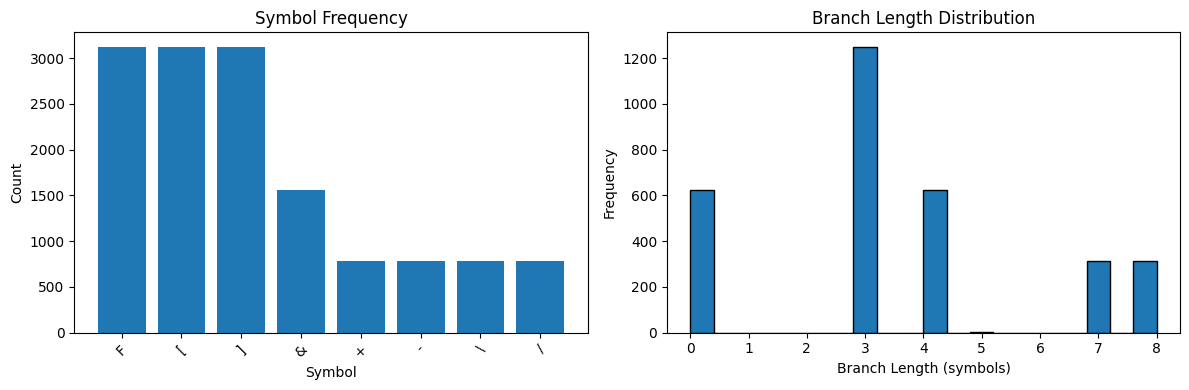

🌲 Generating 3 Tree Variations
Tree 1: Bush, Angle=22.5°, Dist=1.2, Iter=5
Tree 2: Fractal Tree, Angle=16.4°, Dist=1.0, Iter=3
Tree 3: Realistic Tree, Angle=34.1°, Dist=1.2, Iter=4


In [ ]:
# Advanced Analysis Tools
def analyze_l_system_patterns():
    """Advanced analysis of L-system patterns"""

    from collections import Counter
    import pandas as pd
    import matplotlib.pyplot as plt

    if not current_tree:
        print("No tree generated yet!")
        return

    # Analyze L-string patterns
    l_string = current_tree.state

    print("🔍 Advanced L-System Analysis")
    print("=" * 40)

    # 1. Symbol frequency
    symbol_counts = Counter(l_string)
    print("\n1. Symbol Frequency:")
    for symbol, count in symbol_counts.most_common():
        percentage = (count / len(l_string)) * 100
        print(f"   '{symbol}': {count} ({percentage:.1f}%)")

    # 2. Pattern analysis
    print("\n2. Common Patterns:")

    # Look for common sequences
    sequences = []
    for i in range(len(l_string) - 2):
        sequences.append(l_string[i:i+3])

    seq_counts = Counter(sequences)
    print("   Most common 3-symbol sequences:")
    for seq, count in seq_counts.most_common(5):
        print(f"   '{seq}': {count} times")

    # 3. Branching analysis
    opening = l_string.count('[')
    closing = l_string.count(']')
    print(f"\n3. Branching Analysis:")
    print(f"   Opening brackets '[': {opening}")
    print(f"   Closing brackets ']': {closing}")
    print(f"   Balance: {'✓ Balanced' if opening == closing else '✗ Unbalanced'}")

    # 4. Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Symbol frequency plot
    symbols, counts = zip(*symbol_counts.most_common())
    axes[0].bar(symbols, counts)
    axes[0].set_title('Symbol Frequency')
    axes[0].set_xlabel('Symbol')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    # Sequence length distribution
    seq_lengths = [len(seq) for seq in l_string.split(']')]
    axes[1].hist(seq_lengths, bins=20, edgecolor='black')
    axes[1].set_title('Branch Length Distribution')
    axes[1].set_xlabel('Branch Length (symbols)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    return symbol_counts

# Batch Generation Function
def generate_tree_variations(n_trees=5):
    """Generate multiple tree variations"""

    print(f"🌲 Generating {n_trees} Tree Variations")
    print("=" * 40)

    trees = []
    figures = []

    for i in range(n_trees):
        # Random parameters
        tree_type = random.choice(list(TREE_TYPES.keys()))
        params = TREE_TYPES[tree_type]

        angle = random.uniform(15, 35)
        distance = random.uniform(0.8, 2.2)
        thickness = random.uniform(1.5, 3.5)
        iterations = random.randint(3, 6)

        # Create tree
        tree = ColabLSystem3D(
            axiom=params["axiom"],
            rules=params["rules"],
            angle=angle,
            distance=distance,
            thickness=thickness
        )

        # Generate
        fig = create_tree_3d_plot(
            tree,
            iterations,
            show_leaves=True,
            color_scheme=random.choice(['Brown-Green', 'Autumn', 'Winter'])
        )

        # Update title
        fig.update_layout(title=f"Tree {i+1}: {tree_type} (Angle: {angle:.1f}°)")

        trees.append(tree)
        figures.append(fig)

        print(f"Tree {i+1}: {tree_type}, Angle={angle:.1f}°, "
              f"Dist={distance:.1f}, Iter={iterations}")

    # Display all figures
    for fig in figures:
        display(fig)

    return trees

# Latent Space Visualization (Simplified)
def visualize_latent_space_interpolation():
    """Show interpolation between different tree parameters"""

    print("🌀 Latent Space Interpolation Demo")
    print("=" * 40)

    # Define two different tree styles
    style1 = {
        "name": "Bushy Tree",
        "angle": 35,
        "distance": 0.8,
        "iterations": 4,
        "axiom": "F",
        "rules": {"F": "F[+F][-F]F"}
    }

    style2 = {
        "name": "Tall Tree",
        "angle": 20,
        "distance": 1.8,
        "iterations": 5,
        "axiom": "FA",
        "rules": {"A": "![&FA]/(137.5)[&FA]", "F": "FF"}
    }

    # Interpolate between styles
    steps = 5
    figures = []

    print(f"Interpolating from '{style1['name']}' to '{style2['name']}'")
    print()

    for step in range(steps):
        alpha = step / (steps - 1)

        # Interpolate parameters
        angle = style1["angle"] * (1 - alpha) + style2["angle"] * alpha
        distance = style1["distance"] * (1 - alpha) + style2["distance"] * alpha
        iterations = int(style1["iterations"] * (1 - alpha) + style2["iterations"] * alpha)

        # Choose rules based on alpha
        if alpha < 0.5:
            axiom = style1["axiom"]
            rules = style1["rules"]
        else:
            axiom = style2["axiom"]
            rules = style2["rules"]

        # Create tree
        tree = ColabLSystem3D(
            axiom=axiom,
            rules=rules,
            angle=angle,
            distance=distance,
            thickness=2.0
        )

        # Generate
        fig = create_tree_3d_plot(
            tree,
            iterations,
            show_leaves=True,
            color_scheme='Brown-Green'
        )

        fig.update_layout(title=f"Step {step+1}/{steps} (α={alpha:.2f})")
        figures.append(fig)

        print(f"Step {step+1}: α={alpha:.2f}, Angle={angle:.1f}°, "
              f"Dist={distance:.1f}, Iter={iterations}")

    # Display interpolation sequence
    for fig in figures:
        display(fig)

    print("\n✅ Interpolation complete!")

# Export as HTML for sharing
def export_as_html():
    """Export current tree as interactive HTML"""

    if not current_tree:
        print("No tree to export!")
        return

    # Create a standalone HTML with the tree
    fig = create_tree_3d_plot(
        current_tree,
        iterations_slider.value,
        show_leaves=show_leaves_checkbox.value,
        color_scheme=color_dropdown.value
    )

    # Add statistics to HTML
    stats = create_statistics_panel(current_tree)
    stats_html = "<h3>Tree Statistics</h3><ul>"
    for key, value in stats.items():
        if isinstance(value, float):
            stats_html += f"<li>{key}: {value:.3f}</li>"
        else:
            stats_html += f"<li>{key}: {value}</li>"
    stats_html += "</ul>"

    # Save as HTML
    html_filename = "l_system_tree.html"
    fig.write_html(html_filename, include_plotlyjs='cdn')

    # Read and enhance the HTML
    with open(html_filename, 'r') as f:
        html_content = f.read()

    # Add statistics to the HTML
    enhanced_html = html_content.replace('</body>', f'{stats_html}</body>')

    with open(html_filename, 'w') as f:
        f.write(enhanced_html)

    print(f"📄 HTML exported to {html_filename}")
    print("You can download it with: files.download('l_system_tree.html')")

    # Provide download
    from google.colab import files
    files.download(html_filename)

# Create analysis buttons
analysis_button = widgets.Button(
    description='Analyze Patterns',
    button_style='primary',
    icon='search'
)

variations_button = widgets.Button(
    description='Generate Variations',
    button_style='info',
    icon='cogs'
)

interpolation_button = widgets.Button(
    description='Show Interpolation',
    button_style='success',
    icon='arrows-alt-h'
)

html_export_button = widgets.Button(
    description='Export as HTML',
    button_style='warning',
    icon='file-code'
)

def on_analysis_click(b):
    analyze_l_system_patterns()

def on_variations_click(b):
    generate_tree_variations(3)

def on_interpolation_click(b):
    visualize_latent_space_interpolation()

def on_html_export_click(b):
    export_as_html()

# Set up callbacks
analysis_button.on_click(on_analysis_click)
variations_button.on_click(on_variations_click)
interpolation_button.on_click(on_interpolation_click)
html_export_button.on_click(on_html_export_click)

# Display advanced tools
print("\n" + "=" * 50)
print("🔧 Advanced Tools")
print("=" * 50)

tool_buttons = HBox([
    analysis_button,
    variations_button,
    interpolation_button,
    html_export_button
], layout=Layout(justify_content='center'))

display(tool_buttons)

print("\n💡 Tips for Colab:")
print("1. Use the sliders to adjust tree parameters")
print("2. Click 'Generate Tree' to update the 3D view")
print("3. Use 'Randomize' for unexpected designs")
print("4. Export for use in 3D modeling software")
print("5. Try 'Analyze Patterns' to understand L-system structure")

In [6]:
# First, install required packages
!pip install plotly kaleido -q
!apt-get install -y xvfb  # For headless display
!pip install pyvirtualdisplay -q


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
# Colab Quick Setup (single cell)
!pip install plotly -q
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# Simple example to get started
def simple_tree_example():
    """Quick example for Colab"""
    axiom = "F"
    rules = {"F": "F[+F]F[-F]F"}

    class SimpleLSystem:
        def __init__(self, axiom, rules, angle=25):
            self.axiom = axiom
            self.rules = rules
            self.angle = np.radians(angle)

        def generate(self, iterations):
            state = self.axiom
            for _ in range(iterations):
                new_state = ""
                for char in state:
                    new_state += self.rules.get(char, char)
                state = new_state
            return state

    lsys = SimpleLSystem(axiom, rules, angle=25)
    result = lsys.generate(4)

    print("🌿 Simple L-System Example")
    print(f"Axiom: {axiom}")
    print(f"Rules: {rules}")
    print(f"Result (first 100 chars): {result[:100]}...")
    print(f"Total length: {len(result)} characters")

    # Simple visualization
    fig = go.Figure(data=[go.Scatter(
        x=[0, 1, 2, 3],
        y=[0, 1, 0, 1],
        mode='markers+text',
        text=['Start', 'Rule F', 'Apply', f'Length: {len(result)}']
    )])

    fig.update_layout(title="L-System Generation Process")
    fig.show()

# Run the example
simple_tree_example()

🌿 Simple L-System Example
Axiom: F
Rules: {'F': 'F[+F]F[-F]F'}
Result (first 100 chars): F[+F]F[-F]F[+F[+F]F[-F]F]F[+F]F[-F]F[-F[+F]F[-F]F]F[+F]F[-F]F[+F[+F]F[-F]F[+F[+F]F[-F]F]F[+F]F[-F]F[...
Total length: 1561 characters


In [ ]:
Part 4: Interactive L-System Generator with GUI

In [5]:
try:
    import tkinter as tk
    from tkinter import ttk, scrolledtext
    import matplotlib.pyplot as plt
    from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

    class LSystemGUI:
        """Interactive GUI for L-system generation and exploration"""

        def __init__(self, root):
            self.root = root
            self.root.title("Interactive L-System Generator")
            self.root.geometry("1200x800")

            self.current_lsystem = None
            self.fig = None
            self.canvas = None

            self.setup_ui()

        def setup_ui(self):
            # Create main frames
            control_frame = ttk.Frame(self.root, padding="10")
            control_frame.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))

            display_frame = ttk.Frame(self.root, padding="10")
            display_frame.grid(row=0, column=1, sticky=(tk.W, tk.E, tk.N, tk.S))

            # Configure grid weights
            self.root.columnconfigure(0, weight=1)
            self.root.columnconfigure(1, weight=2)
            self.root.rowconfigure(0, weight=1)

            # Control panel
            ttk.Label(control_frame, text="L-System Parameters",
                     font=('Arial', 14, 'bold')).grid(row=0, column=0, columnspan=2, pady=10)

            # Tree type selection
            ttk.Label(control_frame, text="Tree Type:").grid(row=1, column=0, sticky=tk.W, pady=5)
            self.tree_type = tk.StringVar(value="Realistic")
            tree_types = ["Realistic", "Pine", "Bush", "Stochastic", "Custom"]
            ttk.Combobox(control_frame, textvariable=self.tree_type,
                        values=tree_types, state="readonly").grid(row=1, column=1, pady=5)

            # Iterations slider
            ttk.Label(control_frame, text="Iterations:").grid(row=2, column=0, sticky=tk.W, pady=5)
            self.iterations = tk.IntVar(value=4)
            ttk.Scale(control_frame, from_=1, to=7, variable=self.iterations,
                     orient=tk.HORIZONTAL, command=self.update_slider_label).grid(row=2, column=1, pady=5)
            self.iterations_label = ttk.Label(control_frame, text="4")
            self.iterations_label.grid(row=2, column=2, pady=5)

            # Angle slider
            ttk.Label(control_frame, text="Angle:").grid(row=3, column=0, sticky=tk.W, pady=5)
            self.angle = tk.DoubleVar(value=22.5)
            ttk.Scale(control_frame, from_=5, to=45, variable=self.angle,
                     orient=tk.HORIZONTAL, command=self.update_angle_label).grid(row=3, column=1, pady=5)
            self.angle_label = ttk.Label(control_frame, text="22.5°")
            self.angle_label.grid(row=3, column=2, pady=5)

            # Distance slider
            ttk.Label(control_frame, text="Step Distance:").grid(row=4, column=0, sticky=tk.W, pady=5)
            self.distance = tk.DoubleVar(value=1.0)
            ttk.Scale(control_frame, from_=0.5, to=3.0, variable=self.distance,
                     orient=tk.HORIZONTAL, resolution=0.1,
                     command=self.update_distance_label).grid(row=4, column=1, pady=5)
            self.distance_label = ttk.Label(control_frame, text="1.0")
            self.distance_label.grid(row=4, column=2, pady=5)

            # Custom rules text
            ttk.Label(control_frame, text="Custom Axiom:").grid(row=5, column=0, sticky=tk.W, pady=5)
            self.axiom_var = tk.StringVar(value="F")
            ttk.Entry(control_frame, textvariable=self.axiom_var, width=20).grid(row=5, column=1, pady=5)

            ttk.Label(control_frame, text="Custom Rules:").grid(row=6, column=0, sticky=tk.W, pady=5)
            self.rules_text = scrolledtext.ScrolledText(control_frame, width=30, height=5)
            self.rules_text.grid(row=6, column=1, columnspan=2, pady=5)
            self.rules_text.insert(tk.END, "F: F[+F][-F]")

            # Buttons
            ttk.Button(control_frame, text="Generate Tree",
                      command=self.generate_tree).grid(row=7, column=0, columnspan=3, pady=20)

            ttk.Button(control_frame, text="Randomize",
                      command=self.randomize_params).grid(row=8, column=0, pady=5)

            ttk.Button(control_frame, text="Export as OBJ",
                      command=self.export_obj).grid(row=8, column=1, pady=5)

            ttk.Button(control_frame, text="Analyze",
                      command=self.analyze_tree).grid(row=8, column=2, pady=5)

            # Statistics display
            ttk.Label(control_frame, text="Statistics",
                     font=('Arial', 12, 'bold')).grid(row=9, column=0, columnspan=3, pady=10)

            self.stats_text = scrolledtext.ScrolledText(control_frame, width=35, height=10)
            self.stats_text.grid(row=10, column=0, columnspan=3, pady=5)

            # Display panel for 3D plot
            self.setup_display_panel(display_frame)

        def setup_display_panel(self, parent):
            ttk.Label(parent, text="3D Visualization",
                     font=('Arial', 14, 'bold')).grid(row=0, column=0, pady=10)

            # Matplotlib figure
            self.fig = plt.figure(figsize=(8, 6))
            self.ax = self.fig.add_subplot(111, projection='3d')

            # Embed in Tkinter
            self.canvas = FigureCanvasTkAgg(self.fig, parent)
            self.canvas.get_tk_widget().grid(row=1, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))

            # Configure grid
            parent.columnconfigure(0, weight=1)
            parent.rowconfigure(1, weight=1)

        def update_slider_label(self, value):
            self.iterations_label.config(text=str(int(float(value))))

        def update_angle_label(self, value):
            self.angle_label.config(text=f"{float(value):.1f}°")

        def update_distance_label(self, value):
            self.distance_label.config(text=f"{float(value):.1f}")

        def generate_tree(self):
            tree_type = self.tree_type.get()

            if tree_type == "Realistic":
                self.current_lsystem = create_realistic_tree()
            elif tree_type == "Pine":
                self.current_lsystem = create_pine_tree()
            elif tree_type == "Bush":
                self.current_lsystem = create_bush()
            elif tree_type == "Stochastic":
                self.current_lsystem = create_stochastic_tree()
            else:  # Custom
                axiom = self.axiom_var.get()
                rules_text = self.rules_text.get("1.0", tk.END).strip()
                rules = {}
                for line in rules_text.split('\n'):
                    if ':' in line:
                        key, value = line.split(':', 1)
                        rules[key.strip()] = value.strip()

                self.current_lsystem = LSystem3D(
                    axiom, rules,
                    angle=self.angle.get(),
                    distance=self.distance.get(),
                    thickness=2.0
                )

            # Update parameters
            self.current_lsystem.angle = np.radians(self.angle.get())
            self.current_lsystem.distance = self.distance.get()

            # Generate and plot
            self.ax.clear()
            self.current_lsystem.plot_3d(
                iterations=self.iterations.get(),
                ax=self.ax
            )

            self.canvas.draw()

            # Update statistics
            self.update_statistics()

        def randomize_params(self):
            self.angle.set(random.uniform(15, 35))
            self.distance.set(random.uniform(0.8, 2.5))
            self.iterations.set(random.randint(3, 6))
            self.update_slider_label(self.iterations.get())
            self.update_angle_label(self.angle.get())
            self.update_distance_label(self.distance.get())

        def update_statistics(self):
            if self.current_lsystem:
                analyzer = LSystemAnalyzer()
                stats = analyzer.compute_statistics(self.current_lsystem.state)

                self.stats_text.delete("1.0", tk.END)
                self.stats_text.insert(tk.END, "L-System Statistics:\n\n")
                for key, value in stats.items():
                    self.stats_text.insert(tk.END, f"{key}: {value:.3f}\n")

                # Add string preview
                l_string = self.current_lsystem.state
                preview = l_string[:100] + "..." if len(l_string) > 100 else l_string
                self.stats_text.insert(tk.END, f"\nString preview:\n{preview}")

        def analyze_tree(self):
            if self.current_lsystem:
                analyzer = LSystemAnalyzer()

                # Show more detailed analysis
                tokens = analyzer.parse_l_string(self.current_lsystem.state[:50])

                analysis_window = tk.Toplevel(self.root)
                analysis_window.title("Detailed Analysis")
                analysis_window.geometry("600x400")

                text = scrolledtext.ScrolledText(analysis_window, width=70, height=20)
                text.pack(padx=10, pady=10, fill=tk.BOTH, expand=True)

                text.insert(tk.END, "Detailed L-System Analysis\n")
                text.insert(tk.END, "="*50 + "\n\n")

                text.insert(tk.END, f"Total length: {len(self.current_lsystem.state)}\n")
                text.insert(tk.END, f"First 50 tokens:\n")
                for i, (token, param) in enumerate(tokens[:50]):
                    text.insert(tk.END, f"  {i:3d}: {token}")
                    if param:
                        text.insert(tk.END, f"({param})")
                    text.insert(tk.END, "\n")

        def export_obj(self):
            if self.current_lsystem:
                # Simple OBJ export
                filename = "tree_export.obj"
                with open(filename, 'w') as f:
                    f.write("# L-System Tree Export\n")
                    f.write("# Generated by Interactive L-System Generator\n\n")

                    vertices = []
                    faces = []
                    vertex_index = 1

                    for start, end, thickness in self.current_lsystem.segments:
                        # For simplicity, just export the line segments as thin cylinders
                        vertices.append(f"v {start[0]:.6f} {start[1]:.6f} {start[2]:.6f}\n")
                        vertices.append(f"v {end[0]:.6f} {end[1]:.6f} {end[2]:.6f}\n")

                        if len(vertices) >= 4:
                            f.write(f"l {vertex_index} {vertex_index + 1}\n")
                            vertex_index += 2

                    # Write all vertices
                    f.write("\n".join(vertices))

                print(f"Exported to {filename}")

    def run_gui():
        root = tk.Tk()
        app = LSystemGUI(root)
        root.mainloop()

    print("\n5. Launching Interactive GUI...")
    run_gui()

except ImportError as e:
    print(f"\nNote: GUI requires tkinter and matplotlib. Error: {e}")
    print("On Ubuntu/Debian: sudo apt-get install python3-tk")
    print("On Mac: Should be included with Python")
    print("On Windows: Should be included with Python")


5. Launching Interactive GUI...


TclError: no display name and no $DISPLAY environment variable

In [ ]:
# Colab installation (run in a cell)
!apt-get -y install ffmpeg    # optional but recommended to get MP4 writer
!pip install numpy matplotlib pillow imageio


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
